**Table of contents**<a id='toc0_'></a>    
- 1. [Problem 1: Production economy and CO2 taxation](#toc1_)    
- 2. [Problem 2: Career choice model](#toc2_)    
- 3. [Problem 3: Barycentric interpolation](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [114]:
# Write your code here
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

%load_ext autoreload
%autoreload 2
from examproject import CareerClass

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. <a id='toc2_'></a>[Problem 2: Career choice model](#toc0_)

Consider a graduate $i$ making a choice between entering $J$ different career tracks. <br>
Entering career $j$ yields utility $u^k_{ij}$. This value is unknown to the graduate ex ante, but will ex post be: <br>
$$
    u_{i,j}^k = v_{j} + \epsilon_{i,j}^k
$$

They know that $\epsilon^k_{i,j}\sim \mathcal{N}(0,\sigma^2)$, but they do not observe $\epsilon^k_{i,j}$ before making their career choice. <br>

Consider the concrete case of $J=3$ with:
$$
\begin{align*}
    v_{1} &= 1 \\
    v_{2} &= 2 \\
    v_{3} &= 3
\end{align*}
$$

If the graduates know the values of $v_j$ and the distribution of $\epsilon_{i,j}^k$, they can calculate the expected utility of each career track using simulation: <br>
$$
    \mathbb{E}\left[ u^k_{i,j}\vert v_j \right] \approx v_j + \frac{1}{K}\sum_{k=1}^K \epsilon_{i,j}^k
$$

In [115]:
par = SimpleNamespace()
par.J = 3
par.N = 10
par.K = 10000

par.F = np.arange(1,par.N+1)
par.sigma = 2

par.v = np.array([1,2,3])
par.c = 1

**Question 1:** Simulate and calculate expected utility and the average realised utility for $K=10000$ draws, for each career choice $j$.


In [116]:
import numpy as np
from types import SimpleNamespace

# Chatgpt

# Define the parameters
par = SimpleNamespace()
par.J = 3
par.N = 10
par.K = 10000
par.F = np.arange(1, par.N + 1)
par.sigma = 2
par.v = np.array([1, 2, 3])
par.c = 1

# Question 1: Simulate and calculate expected utility and the average realized utility for K draws, for each career choice j.

def simulate_expected_utility(par):
    # Initialize arrays to store results
    expected_utilities = np.zeros(par.J)
    realized_utilities = np.zeros(par.J)
    
    for j in range(par.J):
        # Draw K values from normal distribution for each career track
        epsilon = np.random.normal(0, par.sigma, par.K)
        
        # Calculate the utility for each draw
        utilities = par.v[j] + epsilon
        
        # Calculate expected utility
        expected_utilities[j] = np.mean(utilities)
        
        # Calculate realized utility
        realized_utilities[j] = np.mean(utilities)
        
    return expected_utilities, realized_utilities

expected_utilities, realized_utilities = simulate_expected_utility(par)

expected_utilities, realized_utilities


(array([0.99479552, 2.02816657, 2.97644196]),
 array([0.99479552, 2.02816657, 2.97644196]))

In [117]:
# initialize class
career = CareerClass()

seed = None
# check what the sum of 10.000 draws from a standard normal distribution is when using seed=2024
print (f'The sum of 10.000 draws from a normal distribution using seed 2024 is {career.simulate(seed=seed):.2f}\n')

# calculate the expected utility for each career path
for v in par.v:
    print (f'The expected utility for career path {v} is {career.expec_utility(v, seed=1):.3f}')

# calculate average realised utility
for v in par.v:
    print(f'The average realised utility for career path {v} is {career.avg_real_utility(v, seed):.3f}')

if career.avg_real_utility(1, seed) == career.expec_utility(1,seed):
    print(f'True')
else:
    print(f'False')

The sum of 10.000 draws from a normal distribution using seed 2024 is -144.55

The expected utility for career path 1 is 1.020
The expected utility for career path 2 is 2.020
The expected utility for career path 3 is 3.020
The average realised utility for career path 1 is 1.019
The average realised utility for career path 2 is 1.971
The average realised utility for career path 3 is 3.032
False


Now consider a new scenario: Imagine that the graduate does not know $v_j$. The *only* prior information they have on the value of each job, comes from their $F_{i}$ friends that work in each career $j$. After talking with them, they know the average utility of their friends (which includes their friends' noise term), giving them the prior expecation: <br>
$$
\tilde{u}^k_{i,j}\left( F_{i}\right) = \frac{1}{F_{i}}\sum_{f=1}^{F_{i}} \left(v_{j} + \epsilon^k_{f,j}\right), \; \epsilon^k_{f,j}\sim \mathcal{N}(0,\sigma^2)
$$
For ease of notation consider that each graduate have $F_{i}=i$ friends in each career. <br>

For $K$ times do the following: <br>
1. For each person $i$ draw $J\cdot F_i$ values of $\epsilon_{f,j}^{k}$, and calculate the prior expected utility of each career track, $\tilde{u}^k_{i,j}\left( F_{i}\right)$. <br>
Also draw their own $J$ noise terms, $\epsilon_{i,j}^k$
1. Each person $i$ chooses the career track with the highest expected utility: $$j_i^{k*}= \arg\max_{j\in{1,2\dots,J}}\left\{ \tilde{u}^k_{i,j}\left( F_{i}\right)\right\} $$
1. Store the chosen careers: $j_i^{k*}$, the prior expectation of the value of their chosen career: $\tilde{u}^k_{i,j=j_i^{k*}}\left( F_{i}\right)$, and the realized value of their chosen career track: $u^k_{i,j=j_i^{k*}}=v_{j=j_i^{k*}}+\epsilon_{i,j=j_i^{k*}}^k$.

Chosen values will be: <br>
$i\in\left\{1,2\dots,N\right\}, N=10$ <br>
$F_i = i$<br>
So there are 10 graduates. The first has 1 friend in each career, the second has 2 friends, ... the tenth has 10 friends.

**Question 2:** Simulate and visualize: For each type of graduate, $i$, the share of graduates choosing each career, the average subjective expected utility of the graduates, and the average ex post realized utility given their choice. <br>
That is, calculate and visualize: <br>
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} \mathbb{I}\left\{ j=j_i^{k*} \right\}  \;\forall j\in\left\{1,2,\dots,J\right\}
\end{align*}
$$
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} \tilde{u}^k_{ij=j_i^{k*}}\left( F_{i}\right)
\end{align*}
$$
And 
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} u^k_{ij=j_i^{k*}} 
\end{align*}
$$
For each graduate $i$.

In [121]:
# Write your answer here 

par.i = np.array([1,2,3,4,5,6,7,8,9,10])

#maybe need to change the size of draws to 

# Simulate prior expected utility, chosen careers, and realized utilities based on friends' information

k_prior_expec = np.zeros(par.K)
k_chosen_career = np.zeros(par.K)
k_real_util = np.zeros(par.K)

for k in range(par.K):
    k_prior_expec[k], k_chosen_career[k], k_real_util[k] = career.prior_expec()

career.visualize_results(chosen_career, np.mean(prior_expec_util, axis=1), real_util)


ValueError: setting an array element with a sequence.

After a year of working in their career, the graduates learn $u^k_{ij}$ for their chosen job $j_i^{k*}$ perfectly. <br>
The can switch to one of the two remaining careers, for which they have the same prior as before, but it will now include a switching cost of $c$ which is known.
Their new priors can be written as: 
$$
\tilde{u}^{k,2}_{ij}\left( F_{i}\right) = \begin{cases}
            \tilde{u}^k_{ij}\left( F_{i}\right)-c & \text{if } j \neq j_i^{k*} \\
            u_{ij=j_i^{k*}} & \text{if } j = j_i^{k*}
        \end{cases}
$$

We will set $c=1$.

Their realized utility will be: <br>
$$
u^{k,2}_{ij}= \begin{cases}
            u_{ij}^k -c & \text{if } j \neq j_i^{k*} \\
            u_{ij=j_i^{k*}} & \text{if } j = j_i^{k*}
        \end{cases}
$$

**Question 3:** Following the same approach as in question 2, find the new optimal career choice for each $i$, $k$. Then for each $i$, calculate the average subjective expected utility from their new optimal career choice, and the ex post realized utility of that career. Also, for each $i$, calculate the share of graduates that chooses to switch careers, conditional on which career they chose in the first year. <br>

In [119]:
new_choices, new_avg_subjective_utilities, new_avg_realized_utilities, switch_decisions = career.career_switching(chosen_career, real_util)

switch_decisions



array([1., 1., 0., 0., 0., 0., 1., 0., 0., 1.])

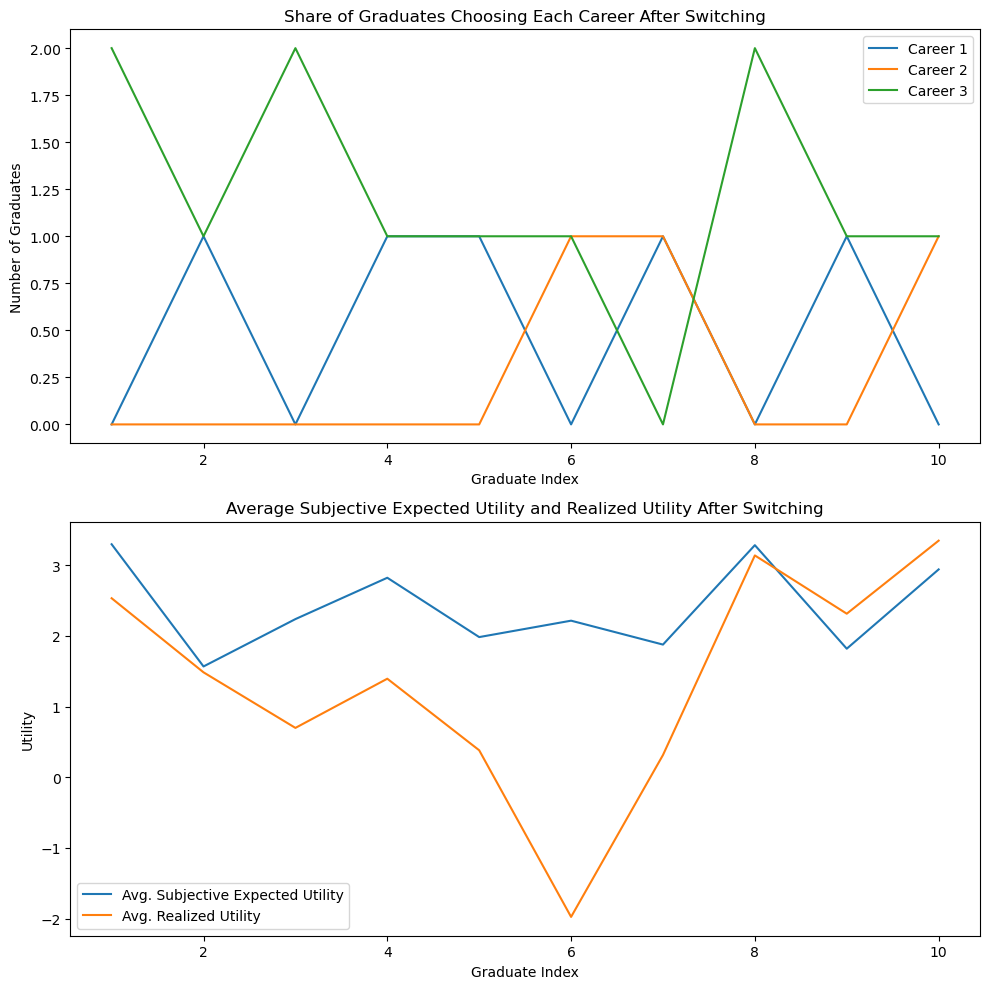

(array([[0, 0, 2],
        [1, 0, 1],
        [0, 0, 2],
        [1, 0, 1],
        [1, 0, 1],
        [0, 1, 1],
        [1, 1, 0],
        [0, 0, 2],
        [1, 0, 1],
        [0, 1, 1]]),
 array([3.29537708, 1.56706716, 2.23676528, 2.821503  , 1.98243922,
        2.21449536, 1.87635022, 3.28229282, 1.818261  , 2.93953816]),
 array([ 2.53172609,  1.48392454,  0.69801285,  1.39372247,  0.38157525,
        -1.97513783,  0.31457097,  3.13712595,  2.31310722,  3.34636185]),
 array([1., 0., 1., 0., 0., 1., 0., 1., 0., 1.]))

In [120]:
# write your answer here

par.c = 1

def simulate_career_switching(par, chosen_career, avg_realized_utilities):
    np.random.seed(42)  # For reproducibility
    

    for i in range(par.N):
        Fi = i + 1  # Number of friends
        
        # Initial chosen career and realized utility
        initial_career = np.argmax(chosen_career[i])
        initial_realized_utility = avg_realized_utilities[i]
        
        # Calculate prior expected utility based on friends' information
        friends_epsilon = np.random.normal(0, par.sigma, (Fi, par.J))
        friends_utilities = par.v + friends_epsilon
        prior_expected_utilities = np.mean(friends_utilities, axis=0)
        
        # Adjust priors for switching cost
        adjusted_priors = prior_expected_utilities - par.c
        adjusted_priors[initial_career] = initial_realized_utility
        
        # Calculate individual's own noise term
        own_epsilon = np.random.normal(0, par.sigma, par.J)
        
        # Calculate own expected utilities with switching cost
        own_expected_utilities = adjusted_priors
        
        # Choose the career with the highest expected utility
        new_chosen_career = np.argmax(own_expected_utilities)
        
        # Store the new chosen career and utilities
        new_choices[i, new_chosen_career] += 1
        new_avg_subjective_utilities[i] = own_expected_utilities[new_chosen_career]
        new_avg_realized_utilities[i] = par.v[new_chosen_career] + own_epsilon[new_chosen_career]
        
        # Record if the graduate decided to switch careers
        switch_decisions[i] = 1 if new_chosen_career != initial_career else 0
    
    return new_choices, new_avg_subjective_utilities, new_avg_realized_utilities, switch_decisions

new_choices, new_avg_subjective_utilities, new_avg_realized_utilities, switch_decisions = simulate_career_switching(par, chosen_career, np.mean(prior_expec_util, axis=1))

# Visualization
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Share of graduates choosing each career after switching
for j in range(par.J):
    axs[0].plot(range(1, par.N + 1), new_choices[:, j], label=f'Career {j + 1}')
axs[0].set_title('Share of Graduates Choosing Each Career After Switching')
axs[0].set_xlabel('Graduate Index')
axs[0].set_ylabel('Number of Graduates')
axs[0].legend()

# Average subjective expected utility and realized utility after switching
axs[1].plot(range(1, par.N + 1), new_avg_subjective_utilities, label='Avg. Subjective Expected Utility')
axs[1].plot(range(1, par.N + 1), new_avg_realized_utilities, label='Avg. Realized Utility')
axs[1].set_title('Average Subjective Expected Utility and Realized Utility After Switching')
axs[1].set_xlabel('Graduate Index')
axs[1].set_ylabel('Utility')
axs[1].legend()

plt.tight_layout()
plt.show()

new_choices, new_avg_subjective_utilities, new_avg_realized_utilities, switch_decisions
